In [8]:
import pandas as pd 
import numpy as np

## Exercise 1 : Wildlife Strikes

#### Part 1 - Import and Explore Data

#####  1. Import the dataset strikes.csv with the functions read_csv of the library pandas 

In [9]:
# Import the data
data = pd.read_csv('strikes.csv')


##### 2. Exploration of the data

In [10]:
# a. Shapes of the data
# write your code here
print("Shape of the data:", data.shape)
#78 row and 94 columns


Shape of the data: (78, 94)


In [11]:
# b. Display the four first rows of the DataFrame, the five last rows
# write your code here
row = data.head(4)
print("The four first rows of the DataFrame:")
print(row)
last_rows = data.tail(5)
print("The five last rows of the DataFrame:")
print(last_rows)

The four first rows of the DataFrame:
   INDEX_NR OPID           OPERATOR      ATYPE  AMA   AMO   EMA   EMO  \
0    100000  AAL  AMERICAN AIRLINES      B-727  148  10.0  34.0  10.0   
1    100001  UAL    UNITED AIRLINES  B-737-300  148  24.0  10.0   1.0   
2    100002  UAL    UNITED AIRLINES  B-737-300  148  24.0  10.0   1.0   
3    100003  UAL    UNITED AIRLINES  B-757-200  148  26.0  34.0  40.0   

  AC_CLASS  AC_MASS  ...  REPORTED_NAME REPORTED_TITLE        REPORTED_DATE  \
0        A      4.0  ...        Deleted        Deleted  1992-05-14 00:00:00   
1        A      4.0  ...        Deleted        Deleted                  NaN   
2        A      4.0  ...        Deleted        Deleted                  NaN   
3        A      4.0  ...        Deleted        Deleted                  NaN   

                 SOURCE                    PERSON  NR_INJURIES NR_FATALITIES  \
0       FAA Form 5200-7                     Pilot          NaN           NaN   
1  Air Transport Report  Air Transport O

In [12]:
# c. Display the columns and row names
# write your code here
print("Columns names:")
print(data.columns)
print("Row names:")
print(data.index)

Columns names:
Index(['INDEX_NR', 'OPID', 'OPERATOR', 'ATYPE', 'AMA', 'AMO', 'EMA', 'EMO',
       'AC_CLASS', 'AC_MASS', 'NUM_ENGS', 'TYPE_ENG', 'ENG_1_POS', 'ENG_2_POS',
       'ENG_3_POS', 'ENG_4_POS', 'REG', 'FLT', 'REMAINS_COLLECTED',
       'REMAINS_SENT', 'INCIDENT_DATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR',
       'TIME_OF_DAY', 'TIME', 'AIRPORT_ID', 'AIRPORT', 'STATE', 'FAAREGION',
       'ENROUTE', 'RUNWAY', 'LOCATION', 'HEIGHT', 'SPEED', 'DISTANCE',
       'PHASE_OF_FLT', 'DAMAGE', 'STR_RAD', 'DAM_RAD', 'STR_WINDSHLD',
       'DAM_WINDSHLD', 'STR_NOSE', 'DAM_NOSE', 'STR_ENG1', 'DAM_ENG1',
       'STR_ENG2', 'DAM_ENG2', 'STR_ENG3', 'DAM_ENG3', 'STR_ENG4', 'DAM_ENG4',
       'INGESTED', 'STR_PROP', 'DAM_PROP', 'STR_WING_ROT', 'DAM_WING_ROT',
       'STR_FUSE', 'DAM_FUSE', 'STR_LG', 'DAM_LG', 'STR_TAIL', 'DAM_TAIL',
       'STR_LGHTS', 'DAM_LGHTS', 'STR_OTHER', 'DAM_OTHER', 'OTHER_SPECIFY',
       'EFFECT', 'EFFECT_OTHER', 'SKY', 'PRECIP', 'SPECIES_ID', 'SPECIES',
       'BIRDS_SE

In [13]:
# d.	Get the number of occurances of birdstrike for each airline operator using the function value_count(). Save this number into the variable operator_counts. What is the type of this variable?
# write your code here
operator_counts = data['OPERATOR'].value_counts()
print("Number of occurrences of birdstrike for each airline operator:")
print(operator_counts)
print("Type of operator_counts variable:", type(operator_counts))

Number of occurrences of birdstrike for each airline operator:
OPERATOR
UNKNOWN                           13
UNITED AIRLINES                   10
AMERICAN AIRLINES                  9
SKYWEST AIRLINES                   6
MILITARY                           5
UPS AIRLINES                       3
BUSINESS                           3
FEDEX EXPRESS                      3
SOUTHWEST AIRLINES                 2
PINNACLE                           2
CONTINENTAL AIRLINES               2
ATLANTIC SOUTHEAST                 2
ABX AIR                            2
MESA AIRLINES                      2
EXPRESSJET AIRLINES                2
AIR MIDWEST                        1
AMERICAN EAGLE AIRLINES            1
COMAIR AIRLINES                    1
WINGS WEST                         1
AMERICA WEST AIRLINES              1
CHAUTAUQUA AIRLINES                1
EXPRESSJET (CONTINENTAL EXPRS)     1
AIRTRAN AIRWAYS                    1
CAPE AIR                           1
HORIZON AIR                        1
SUN

In [14]:
# e. Save the Operator name in a variable
# write your code here
operator_name = data['OPERATOR']
print("Operator names:")
print(operator_name)


Operator names:
0     AMERICAN AIRLINES
1       UNITED AIRLINES
2       UNITED AIRLINES
3       UNITED AIRLINES
4       UNITED AIRLINES
            ...        
73             MILITARY
74             MILITARY
75             MILITARY
76             MILITARY
77             MILITARY
Name: OPERATOR, Length: 78, dtype: str


In [15]:
# f. Save the counts in another variable transforming the dataframe operator_counts into a numpy array.
# write your code here
operator_counts_array = operator_counts.values
print("Counts of birdstrike for each airline operator as a numpy array:")
print(operator_counts_array)



Counts of birdstrike for each airline operator as a numpy array:
[13 10  9  6  5  3  3  3  2  2  2  2  2  2  2  1  1  1  1  1  1  1  1  1
  1  1  1]


#### Part 2 - Data Cleaning

##### Missing Value: 

# 1. Check the number of missing values per columns. 

3.	Decide: 
a.	Which columns should be dropped ?
b.	Which columns should be filled ?
c.	Fill missing values 



In [16]:
# write your code here
#Check the number of missing values per columns. 
missing_values = data.isnull().sum()
missing_columns = missing_values[missing_values > 0].sort_values(ascending=False)
print("Columns with missing values (sorted):")
print(missing_columns)

# Show only the middle records of columns with missing values
mid_start = len(missing_columns) // 3
mid_end = 2 * len(missing_columns) // 3
print("Middle columns with missing values:")
print(missing_columns.iloc[mid_start:mid_end])

# sort column with highest number of missing values to lowest
high_missing_value = missing_values.sort_values(ascending=False)
print("Columns sorted by number of missing values (highest to lowest):")
print(high_missing_value)


Columns with missing values (sorted):
ENG_4_POS                78
COST_OTHER               78
NR_INJURIES              78
NR_FATALITIES            78
COST_OTHER_INFL_ADJ      78
EFFECT_OTHER             78
ENROUTE                  78
COST_REPAIRS_INFL_ADJ    75
COST_REPAIRS             75
AOS                      74
EFFECT                   74
ENG_3_POS                72
PRECIP                   71
LOCATION                 71
OTHER_SPECIFY            70
REPORTED_DATE            61
TIME                     52
BIRDS_SEEN               51
SPEED                    50
WARNED                   47
FLT                      42
REG                      40
SKY                      39
DISTANCE                 37
TIME_OF_DAY              37
RUNWAY                   29
COMMENTS                 27
HEIGHT                   23
EMO                      21
DAMAGE                   21
EMA                      20
PHASE_OF_FLT             20
AMO                      19
REMARKS                  18
ENG_2_POS 

In [17]:
# 2.	Calculated the percentages of missing values. 
# write your code here
total_rows = len(data)
missing_percentages = (missing_values / total_rows) * 100
missing_percentages_sorted = missing_percentages.sort_values(ascending=False)
print("Percentage of missing values for each column (sorted):")
print(missing_percentages_sorted)




Percentage of missing values for each column (sorted):
ENROUTE                100.0
ENG_4_POS              100.0
NR_INJURIES            100.0
NR_FATALITIES          100.0
COST_OTHER_INFL_ADJ    100.0
                       ...  
STR_LGHTS                0.0
SOURCE                   0.0
LUPDATE                  0.0
TRANSFER                 0.0
INDICATED_DAMAGE         0.0
Length: 94, dtype: float64


In [18]:
# 3.	Decide: 
        # a.	Which columns should be dropped ?
['ENG_3_POS', 'ENG_4_POS', 'REG', 'FLT', 'TIME', 'ENROUTE', 'LOCATION', 'SPEED', 'OTHER_SPECIFY', 'EFFECT', 'EFFECT_OTHER', 'PRECIP', 'BIRDS_SEEN', 'WARNED', 'AOS', 'COST_REPAIRS', 'COST_OTHER', 'COST_REPAIRS_INFL_ADJ', 'COST_OTHER_INFL_ADJ', 'REPORTED_DATE', 'NR_INJURIES', 'NR_FATALITIES']
        # b.	Which columns should be filled ?
['INDEX_NR', 'OPID', 'OPERATOR', 'ATYPE', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'NUM_ENGS', 'TYPE_ENG', 'ENG_1_POS', 'ENG_2_POS', 'REG', 'FLT', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'INCIDENT_DATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME_OF_DAY', 'TIME', 'AIRPORT_ID', 'AIRPORT', 'STATE', 'FAAREGION', 'RUNWAY', 'HEIGHT', 'SPEED', 'DISTANCE', 'PHASE_OF_FLT', 'DAMAGE', 'STR_RAD', 'DAM_RAD', 'STR_WINDSHLD', 'DAM_WINDSHLD', 'STR_NOSE', 'DAM_NOSE', 'STR_ENG1', 'DAM_ENG1', 'STR_ENG2', 'DAM_ENG2', 'STR_ENG3', 'DAM_ENG3', 'STR_ENG4', 'DAM_ENG4', 'INGESTED', 'STR_PROP', 'DAM_PROP', 'STR_WING_ROT', 'DAM_WING_ROT', 'STR_FUSE', 'DAM_FUSE', 'STR_LG', 'DAM_LG', 'STR_TAIL', 'DAM_TAIL', 'STR_LGHTS', 'DAM_LGHTS', 'STR_OTHER', 'DAM_OTHER', 'SKY', 'SPECIES_ID', 'SPECIES', 'BIRDS_SEEN', 'BIRDS_STRUCK', 'SIZE', 'WARNED', 'COMMENTS', 'REMARKS', 'REPORTED_NAME', 'REPORTED_TITLE', 'REPORTED_DATE', 'SOURCE', 'PERSON', 'LUPDATE', 'TRANSFER', 'INDICATED_DAMAGE']
        # c.	Fill missing values 

['INDEX_NR',
 'OPID',
 'OPERATOR',
 'ATYPE',
 'AMA',
 'AMO',
 'EMA',
 'EMO',
 'AC_CLASS',
 'AC_MASS',
 'NUM_ENGS',
 'TYPE_ENG',
 'ENG_1_POS',
 'ENG_2_POS',
 'REG',
 'FLT',
 'REMAINS_COLLECTED',
 'REMAINS_SENT',
 'INCIDENT_DATE',
 'INCIDENT_MONTH',
 'INCIDENT_YEAR',
 'TIME_OF_DAY',
 'TIME',
 'AIRPORT_ID',
 'AIRPORT',
 'STATE',
 'FAAREGION',
 'RUNWAY',
 'HEIGHT',
 'SPEED',
 'DISTANCE',
 'PHASE_OF_FLT',
 'DAMAGE',
 'STR_RAD',
 'DAM_RAD',
 'STR_WINDSHLD',
 'DAM_WINDSHLD',
 'STR_NOSE',
 'DAM_NOSE',
 'STR_ENG1',
 'DAM_ENG1',
 'STR_ENG2',
 'DAM_ENG2',
 'STR_ENG3',
 'DAM_ENG3',
 'STR_ENG4',
 'DAM_ENG4',
 'INGESTED',
 'STR_PROP',
 'DAM_PROP',
 'STR_WING_ROT',
 'DAM_WING_ROT',
 'STR_FUSE',
 'DAM_FUSE',
 'STR_LG',
 'DAM_LG',
 'STR_TAIL',
 'DAM_TAIL',
 'STR_LGHTS',
 'DAM_LGHTS',
 'STR_OTHER',
 'DAM_OTHER',
 'SKY',
 'SPECIES_ID',
 'SPECIES',
 'BIRDS_SEEN',
 'BIRDS_STRUCK',
 'SIZE',
 'WARNED',
 'COMMENTS',
 'REMARKS',
 'REPORTED_NAME',
 'REPORTED_TITLE',
 'REPORTED_DATE',
 'SOURCE',
 'PERSON',
 'LUP

In [19]:
# write your code here
# ...existing code...
columns_over_80_missing = missing_percentages[missing_percentages > 80].index.tolist()  # "more than 80%"
print("Columns to drop (more than 80% missing):")
print(columns_over_80_missing)

data_clean = data.drop(columns=columns_over_80_missing)  # or: data = data.drop(...)

#missing value under 80%
columns_under_80_missing = missing_percentages[missing_percentages < 80].index.tolist()
print("Columns to consider filling (less than 80% missing):")   
print(columns_under_80_missing)

Columns to drop (more than 80% missing):
['ENG_3_POS', 'ENG_4_POS', 'ENROUTE', 'LOCATION', 'OTHER_SPECIFY', 'EFFECT', 'EFFECT_OTHER', 'PRECIP', 'AOS', 'COST_REPAIRS', 'COST_OTHER', 'COST_REPAIRS_INFL_ADJ', 'COST_OTHER_INFL_ADJ', 'NR_INJURIES', 'NR_FATALITIES']
Columns to consider filling (less than 80% missing):
['INDEX_NR', 'OPID', 'OPERATOR', 'ATYPE', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'NUM_ENGS', 'TYPE_ENG', 'ENG_1_POS', 'ENG_2_POS', 'REG', 'FLT', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'INCIDENT_DATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME_OF_DAY', 'TIME', 'AIRPORT_ID', 'AIRPORT', 'STATE', 'FAAREGION', 'RUNWAY', 'HEIGHT', 'SPEED', 'DISTANCE', 'PHASE_OF_FLT', 'DAMAGE', 'STR_RAD', 'DAM_RAD', 'STR_WINDSHLD', 'DAM_WINDSHLD', 'STR_NOSE', 'DAM_NOSE', 'STR_ENG1', 'DAM_ENG1', 'STR_ENG2', 'DAM_ENG2', 'STR_ENG3', 'DAM_ENG3', 'STR_ENG4', 'DAM_ENG4', 'INGESTED', 'STR_PROP', 'DAM_PROP', 'STR_WING_ROT', 'DAM_WING_ROT', 'STR_FUSE', 'DAM_FUSE', 'STR_LG', 'DAM_LG', 'STR_TAIL', 'DAM_

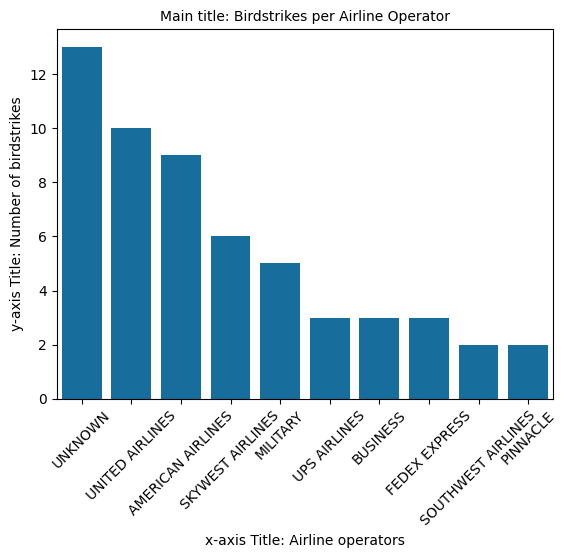

In [20]:
# 4.	We now want to create barplots using the libraries matplotlib and seaborn to visualize occurances of birdstrike per airline operator. Comment the following lines
import matplotlib.pyplot as plt
import seaborn as sns

operators = operator_counts.index
counts = operator_counts.values

paired_palette = sns.color_palette("colorblind")
sns.set_palette(paired_palette, 10)
plt.xticks(rotation=45)
plt.xlabel("x-axis Title: Airline operators", fontsize=10)
plt.ylabel("y-axis Title: Number of birdstrikes", fontsize=10)
plt.title("Main title: Birdstrikes per Airline Operator", fontsize=10)
barplot = sns.barplot(x=operators[:10], y=counts[:10])

## Exercise 2: Survival on titanic dataset

#### Part 1 - Importation of the data and description of the dataset

In [21]:
# 1.	In the first practical session, download the dataset and set the dataset as Dataframe. 
# write your code here
import pandas as pd
import numpy as np
data = pd.read_csv('titanic.csv')


In [22]:
# 2.	Describe the dataset titanic: features, nature of the features, number of observations. 
# write your code here
print("Shape of the data:", data.shape)
print("Columns names:")
print(data.columns)
print("Row names:")
print(data.index)

Shape of the data: (891, 12)
Columns names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
Row names:
RangeIndex(start=0, stop=891, step=1)


In [23]:
# 3.	Basic statistics: mean of each variable, quartiles
# write your code here
print("Basic statistics of the dataset:")
print(data.describe())

Basic statistics of the dataset:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [24]:
# 4.	Percentage of missing values for each column. Sort by descending values.
# write your code here
missing_values = data.isnull().sum()
total_rows = len(data)
missing_percentages = (missing_values / total_rows) * 100
missing_percentages_sorted = missing_percentages.sort_values(ascending=False)
print("Percentage of missing values for each column (sorted):")
print(missing_percentages_sorted)

Percentage of missing values for each column (sorted):
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


#### Part 2: Remove Irrelevant Features
Remove : 
-	PassengerId
-	Ticket
-	Name
Explain why these columns are removed. ( 2 – 3 Paragraph). (Write in Markdown)

#### Part 3: Missing Values 

# write your code here


In [25]:
# 1.	Compute missing value percentages.
# write your code here
missing_values = data.isnull().sum()
total_rows = len(data)
missing_percentages = (missing_values / total_rows) * 100
print("Percentage of missing values for each column:")
print(missing_percentages)
#  


Percentage of missing values for each column:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [26]:
# 2.	Handing missing values:
# •	Age -> median 
median_age = data['Age'].median()
data['Age'].fillna(median_age, inplace=True)
# •	Embarked -> mode 
mode_embarked = data['Embarked'].mode()[0]
data['Embarked'].fillna(mode_embarked, inplace=True)
# •	Cabin -> drop or justify decision
data.drop(columns=['Cabin'], inplace=True)

C:\Users\youdy\AppData\Local\Temp\ipykernel_13812\424462334.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Age'].fillna(median_age, inplace=True)
C:\Users\youdy\AppData\Local\Temp\ipykernel_13812\424462334.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using

Part 4: Encoding
Encode: 
-	Sex
-	Embarked 
Use: 
-	Label Encoding or one-hot Encoding

In [27]:

# Sex (binary) -> label encoding
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})

# Embarked (nominal) -> one-hot encoding
data = pd.get_dummies(data, columns=["Embarked"], prefix="Embarked", drop_first=True, dtype=int)

print(data[["Sex", "Embarked_Q", "Embarked_S"]].head())



   Sex  Embarked_Q  Embarked_S
0    0           0           1
1    1           0           0
2    1           0           1
3    1           0           1
4    0           0           1


#### Part 5: Scaling
1.	Scale numerical features: 
•	Age 
•	Fare
Use:
•	Min-Max Scaling or Standardization

In [33]:
# write your code here
# ...existing code...
from sklearn.preprocessing import MinMaxScaler  # or StandardScaler

scaler = MinMaxScaler()  # change to StandardScaler() 
data[["Age", "Fare"]] = scaler.fit_transform(data[["Age", "Fare"]])

print(data[["Age", "Fare"]].head())
# ...existing code...


        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713


#### Part 6: Outlier Detection

In [34]:
# 1.	Detect outlier in Fare using IQR 
# write your code here
Q1 = data["Fare"].quantile(0.25)
Q3 = data["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = data[(data["Fare"] < lower_bound) | (data["Fare"] > upper_bound)]
print("Number of Fare outliers:", fare_outliers.shape[0])
print(fare_outliers[["Fare"]].head())


Number of Fare outliers: 116
        Fare
1   0.139136
27  0.513342
31  0.285990
34  0.160387
52  0.149765


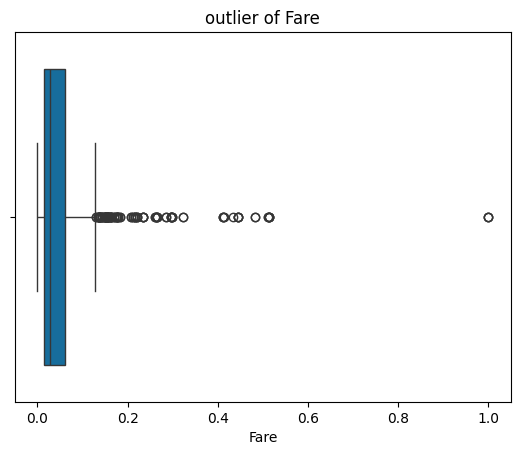

In [36]:
# 2. Visualization using boxplot 
# write your code here
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=data["Fare"])
plt.title("outlier of Fare")
plt.xlabel("Fare")
plt.show()

In [31]:
# 3.	Explain whether you remove them or not ?
# write your code here

Basic graphic analysis
We want to understand what features could contributes to a high survival rate. It would make sense if everything would be correlated with a high survival rate. 
1.	We focus on the features ‘Age’ and ‘Sex’
a.	Separate the dataset into men and women 
b.	Display the distribution of the age survivors and non survivors according to the ‘Sex’. 
2.	At first glance is there some link between ‘Embarked’ and ‘Survival’. 
3.	At first glance is there some link between ‘Pclass’ and ‘Survival’.

Write your explaination in the markdowns !

write your explain here ! 